# Introduction

**Concept** <br>
Fit a *single GEV distribution* using annual maxima from **pooled data** and compute *stationary GEV analysis* for 
**annually grouped data**.<br>

**Options**
- **Option1**<br>
    pool all data per location for global stationary and non-stationary analysis<br><br>
- **Option2**<br>
    per year grouped data per location for stationary analysis<br>

---
**Workflow Summary (per location)**
1. Extract annual maxima → fit stationary & non-stationary GEV per model
2. Compute return levels & CIs per year per model
3. Compute exceedance probability & CI for thresholds of interest
4. Aggregate multi-model ensemble: mean + total spread
5. Visualization
   1. Return levels vs year (shaded CI)
   2. Probability amplification vs year (shaded CI)
   3. Multi-model ensemble bar plots for future RL
   4. Maps (mean & spread)
6. Tables:
   1. RL per T per year ± CI
   2. Probability change of historical RL


**CHECK** STD Calculation! it is basically 0 and doesnt really make sense 

# Import Packages

In [2]:
from datetime import datetime
from glob import glob
from pathlib import Path
import pickle
import warnings
#import random
import matplotlib.pyplot as plt

import func_gev as gev
import func_preparation as dbf
import func_plotting as dbplt
import func_utils as ut

#from numpy import arange

warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline

# Settings

In [3]:
path_input = '../input/Annual_max_DCPP_20260112/'
path_export = '../output/gev_analysis/'

HINDCAST_START = 1960
HINDCAST_END = 2026

RETURN_PERIODS = [10, 25, 50, 100, 200]
RETURN_PERIOD_EVAL = 50
PLOT_PERIOD_EVOLUTION = ['10-year', '50-year', '100-year']
LS_T_EVAL = 1961, 1970, 1990, 2010, 2025, 2050 
T_EVAL_BASE = 1961
CONFIDENCE_INTERVAL = 0.9 # 90% confidence interval assuming two-side model (equal distribution)
export_report=True
DISPLAY_RESULTS = False

# adding a little randomness to enhance trust the model works as robust as possible cross locations..
start_location = 0   # random.choice(arange(0, 9579))
end_location = 200     # start_location+10
print(f'analyse a subsample of location {start_location}–{end_location}')

colors = [
    '#53354DFF','#7D4F73FF','#B887ADFF','#CAA5C2FF','#DBC3D6FF','#F5F5F5FF','#99E3DDFF',
    '#66D4CCFF','#33C6BBFF','#008A80FF','#005C55FF'
    ]

analyse a subsample of location 0–200


# Import Data

In [4]:
ls_files = [file for file in glob(path_input + '*.nc')]

print('Importing Data from ...')
print("\n".join(ls_files))

dic_data_per_model = dbf.import_all_models(ls_files)

Importing Data from ...
../input/Annual_max_DCPP_20260112/Annual_max_MIROC6.nc
../input/Annual_max_DCPP_20260112/Annual_max_MPI-ESM1-2-HR.nc
../input/Annual_max_DCPP_20260112/Annual_max_HadGEM3-GC31-MM.nc
../input/Annual_max_DCPP_20260112/Annual_max_MRI-ESM2-0.nc
../input/Annual_max_DCPP_20260112/Annual_max_BCC-CSM2-MR.nc
../input/Annual_max_DCPP_20260112/Annual_max_CMCC-CM2-SR5.nc
../input/Annual_max_DCPP_20260112/Annual_max_CanESM5.nc
../input/Annual_max_DCPP_20260112/Annual_max_NorCPM1.nc


# Prepare Data

### Pooling, BiasCorrection, ValidityCheck

In [5]:
print('Pooling and Preparing Data...')
dic_data_per_model, combined, notes_overview = dbf.prepare_combined_data(ls_files, dic_data_per_model)
print('... done.')

Pooling and Preparing Data...
... done.


### Rearrangement > Data Per Location

In [6]:
print('Rearranging Data – sorting per location...')    
dic_data_per_location = dbf.extract_location_data(combined, hindcast_start=HINDCAST_START, hindcast_end=HINDCAST_END)

Rearranging Data – sorting per location...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    5.2s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    5.2s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    5.3s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.1987933399844875s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    5.4s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    5.5s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.14467096328735352s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:    5.6s
[Parallel(n_jobs=-1)]: Done 128 tasks      | elapsed:    5.9s
[Parallel(n_jobs=-1)]: Done 188 tasks      | elapsed:    6.1s
[Parallel(n_jobs=-1)]: Done 248 tasks      | elapsed:    6.3s
[Parallel(n_jobs=-1)]: Done 316 tasks      | elapse

### Select Subset

In [7]:
dic_data_per_location_selected = dbf.crop_to_location_range(dic_data_per_location, start_location, end_location)

Processing locations 0 to 200 (201 total)
Getting closest point available as location label for orientation. 
Note this is not the exact location...


# (Non-)Stationary GEV Analysis with Pooled Data

When fitting a GEV to annual maxima, there are multiple sources of uncertainty in GEV analysis
- Parameter uncertainty (estimation uncertainty)
- Natural variability / return level uncertainty

**Parameter uncertainty**<br>
The GEV has parameters $(μ, σ, ξ)$ <br>
Each of these parameters is estimated from finite data, so each has an associated uncertainty.
This “uncertainty in the location parameter" can be captured by:
- Parametric sampling: sample $μ ~ Normal(μ, SE_μ)$
- Bootstrap: refit GEV on resampled data
- Delta Method (because the others are too instable)

**Natural variability / return level uncertainty** <br>
Even if parameters were known exactly, extreme values themselves are random.
The return level $z_T$ is defined as a high quantile of the GEV:<br>
$z_T = μ + σ/ξ · [(-ln(1-1/T))^ξ - 1]$
<br>

When sampling from fitted GEV distribution, we can get a confidence interval for $z_T$ given fixed parameters.
This is the *return level uncertainty* captured by `gev_return_levels_ci`.

**Key Differences**
|Concept| How it's captured| Effect|
|---|---|---|
|μ (location) uncertainty	|Parametric bootstrap or μ-sampling from estimated SE	|Adds spread to the estimated parameter itself|
|Return level uncertainty	|Sampling from GEV with fixed parameters	|Adds spread due to natural variability of extremes|
|Combined uncertainty	|Sample μ from its distribution, then compute z_T from each μ	|Gives realistic CIs for return levels, including both sources|


In practice, best approach:
- Sample μ (location) from its uncertainty distribution
- For each μ, compute the return level $z_T$ using the quantile formula
- Compute percentile (median, 95% CI) → includes both parameter uncertainty and natural variability

**EXPECTATION TOWARDS VALUES**<br>
In a stationary Generalized Extreme Value distribution:
- μ(mu) = constant → location parameter
- σ(sigma) = constant → scale parameter
- ξ(xi) = constant → shape parameter<br>

So the distribution does not depend on time.
Therefore, $z_T = f(μ,σ,ξ)$ depends only on T, not on time.

---
**NOTE**
- uncertainty is computed using delta method
- for return levels, the uncertainty in sigma, xi are ignored
- weighted nonstationary STDs >>> tried Fisher, Bootstrap but all unreasonable values... go back to delta method
- on return period<br>
  Giant values are not necessarily wrong — they indicate that some parameter combinations imply the reference event becomes almost impossible in later years. But when reporting uncertainty, researchers usually truncate the tail so that a few pathological samples don't dominate the mean.


## Compute for 1 Sample

In [ ]:
## Testing for 1 location 
uncertainty = 'delta'
B = 300             # bootstrap number ideally B ~ 300-500
seed = None
min_years = 10
loc_select = 7

# ----------------------------------------------------------------------------------------------------------
location_labels = dbf.precompute_location_labels(dic_data_per_location_selected)
location_items = []
for loc_id, df in dic_data_per_location_selected.items():
    lon = round(df.lon.unique()[0], 6)
    lat = round(df.lat.unique()[0], 6)
    label = location_labels.get((lon, lat), "unknown location")

    location_items.append((loc_id, df, label))

# -------------------------------------------------------------------------------------------
loc_id = location_items[loc_select][0]
df_prepared = location_items[loc_select][1]
location_info = location_items[loc_select][2]

lon_loc = df_prepared.lon.unique()[0]
lat_loc = df_prepared.lat.unique()[0]

# -------------------------------------------------------------------------------------------
print(f'GEV analysis for location {loc_id} · {location_info}')
results = dict()
ls_notes = []

annual_max = gev.extract_annual_maxima_at_location(df_prepared, lon=lon_loc, lat=lat_loc)

if len(annual_max) < min_years:
    print(
        f'WARNING - not enough data (<{min_years}) for location {loc_id} (lon|lat · {lon_loc}|{lat_loc})'
    )
        
years = annual_max['year'].values
data = annual_max['annual_max'].values
    
# -------------------------------------------------------------------------------------------
pooled_gev, ls_notes = gev.fit_pooled_gev_with_uncertainty(
        loc_id=loc_id, data=data, years=years, B=B, seed=seed, print_msg=True
    )
print(f"\t\tLoc {loc_id} | → (Non-)Stationary GEV done (success {pooled_gev != None})")

# -------------------------------------------------------------------------------------------
print(f"\tLoc {loc_id} | Compare Models...")
comparison = gev.compare_stationary_nonstationary(
    pooled_gev['stationary'], pooled_gev['nonstationary'], annual_max
    )

# -------------------------------------------------------------------------------------------
print(f"\tLoc {loc_id} | Compute Return Levels...")
df_all_return_levels = gev.compute_all_return_levels(
    stationary=pooled_gev['stationary'], nonstationary=pooled_gev['nonstationary'], return_periods=RETURN_PERIODS, 
    ls_t_eval=LS_T_EVAL, confidence_level_pc=CONFIDENCE_INTERVAL
    )

# -------------------------------------------------------------------------------------------
print(f"\tLoc {loc_id} | Compute Return Period of the {RETURN_PERIOD_EVAL}-year event at {T_EVAL_BASE}...")
rp_ns = gev.rp_uncertainty_monte_carlo(
    params=pooled_gev['nonstationary']['params_hat'], cov=pooled_gev['nonstationary']['cov'],  years=years, 
    mean_year=pooled_gev['nonstationary']['years_mean'], std_year=pooled_gev['nonstationary']['years_std'],
    ref_year=T_EVAL_BASE, T_ref=RETURN_PERIOD_EVAL
    )
pooled_gev['nonstationary'].update({'return_period': rp_ns})


# -------------------------------------------------------------------------------------------
results[loc_id] = dict({
    'location_info': location_info,
    'LatLon': (lat_loc, lon_loc),
    'data':annual_max, 
    'stationary': pooled_gev['stationary'],
    'nonstationary': pooled_gev['nonstationary'],
    'model_comparison': comparison,
    'return_levels': df_all_return_levels
    })

## Compute for Multiple

In [ ]:
uncertainty = 'delta'
B = 300             
seed = None
min_years = 10
ls_loc_select = list(dic_data_per_location_selected.keys())[30:40] # take the first 10 locations to see if it works... 

# ----------------------------------------------------------------------------------------------------------
location_labels = dbf.precompute_location_labels(dic_data_per_location_selected)
location_items = []
for loc_id, df in dic_data_per_location_selected.items():
    lon = round(df.lon.unique()[0], 6)
    lat = round(df.lat.unique()[0], 6)
    label = location_labels.get((lon, lat), "unknown location")

    location_items.append((loc_id, df, label))

# -------------------------------------------------------------------------------------------
results = dict()
for loc_select in ls_loc_select:
    loc_id = location_items[loc_select][0]
    df_prepared = location_items[loc_select][1]
    location_info = location_items[loc_select][2]

    lon_loc = df_prepared.lon.unique()[0]
    lat_loc = df_prepared.lat.unique()[0]

    # -------------------------------------------------------------------------------------------
    print(f'GEV analysis for location {loc_id} · {location_info}')
    ls_notes = []

    annual_max = gev.extract_annual_maxima_at_location(df_prepared, lon=lon_loc, lat=lat_loc)

    if len(annual_max) < min_years:
        print(
            'WARNING - not enough data (<%s) for location %s (lon|lat · %s|%s)', min_years, loc_id, lon_loc, lat_loc
        )
            
    years = annual_max['year'].values
    data = annual_max['annual_max'].values
        
    # -------------------------------------------------------------------------------------------
    pooled_gev, ls_notes = gev.fit_pooled_gev_with_uncertainty(
            loc_id=loc_id, data=data, years=years, B=B, seed=seed, print_msg=True
        )
    print(f'\t\t\t\tLoc {loc_id} | → (Non-)Stationary GEV done (success {pooled_gev!=None})')

    # -------------------------------------------------------------------------------------------
    print(f'\t\tLoc {loc_id} | Compare Models...')
    comparison = gev.compare_stationary_nonstationary(
        pooled_gev['stationary'], pooled_gev['nonstationary'], annual_max
        )

    # -------------------------------------------------------------------------------------------
    print(f'\t\tLoc {loc_id} | Compute Return Levels...')
    df_all_return_levels = gev.compute_all_return_levels(
        stationary=pooled_gev['stationary'], nonstationary=pooled_gev['nonstationary'], 
        return_periods=RETURN_PERIODS, ls_t_eval=LS_T_EVAL, confidence_level_pc=CONFIDENCE_INTERVAL
        )

    # -------------------------------------------------------------------------------------------
    print(f'\t\tLoc {loc_id} | Compute Return Period of the {RETURN_PERIOD_EVAL}-year event at {T_EVAL_BASE}...')
    rp_ns = gev.rp_uncertainty_monte_carlo(
        params=pooled_gev['nonstationary']['params_hat'], cov=pooled_gev['nonstationary']['cov'], 
        years=years, mean_year=pooled_gev['nonstationary']['years_mean'], ref_year=T_EVAL_BASE, 
        std_year=pooled_gev['nonstationary']['years_std'], T_ref=RETURN_PERIOD_EVAL
        )
    pooled_gev['nonstationary'].update({'return_period': rp_ns})
    print(
        f'\t\tLoc {loc_id} | Return Period Overview',
        f'\n\t\t mean: {rp_ns.min().return_period_mean:.2f} – {rp_ns.max().return_period_mean:.2f} years',
        f'\n\t\t lower: {rp_ns.min().return_period_lower:.2f} – {rp_ns.max().return_period_lower:.2f} years',
        f'\n\t\t upper: {rp_ns.min().return_period_upper:.2f} – {rp_ns.max().return_period_upper:.2f} years\n\n'
        )


    # -------------------------------------------------------------------------------------------
    results[loc_id] = dict({
        'location_info': location_info,
        'LatLon': (lat_loc, lon_loc),
        'data':annual_max, 
        'stationary': pooled_gev['stationary'],
        'nonstationary': pooled_gev['nonstationary'],
        'model_comparison': comparison,
        'return_levels': df_all_return_levels
        })

Loading formatted geocoded file...
GEV analysis for location 30 · Vallehermosa Canary Islands ES
		Loc 30 | Compute stationary GEV incl uncertainty
		Loc 30 | MLE results: {'shape': np.float64(-0.11386570470200591), 'location': np.float64(0.13230673393226686), 'scale': np.float64(0.031640012151390395), 'log_likelihood': np.float64(16109.41447502379), 'aic': np.float64(-32212.82895004758), 'bic': np.float64(-32191.77577197049), 'dist_type': 'Weibull', 'tail': 'bounded', 'n_obs': 8248}
		Loc 30 | Stationary GEV fit (n=8248):
			  shape (ξ) = -0.1139 ± 0.0052
			  location = 0.1323 ± 0.0004
			  scale    = 0.0316 ± 0.0003
			  covariance = [[2.71739784e-05 5.74131316e-07 4.13894188e-07]
 [5.74131316e-07 1.42779863e-07 1.80334905e-08]
 [4.13894188e-07 1.80334905e-08 6.54505193e-08]]
			  standard errors = [0.00521287 0.00037786 0.00025583]
		Loc 30 | Compute non-stationary GEV incl uncertainty
			Loc 30 | Nonstationary GEV - MLE [ 0.13231113 -0.00015248  0.03164186 -0.11397095]
			Loc 30 |

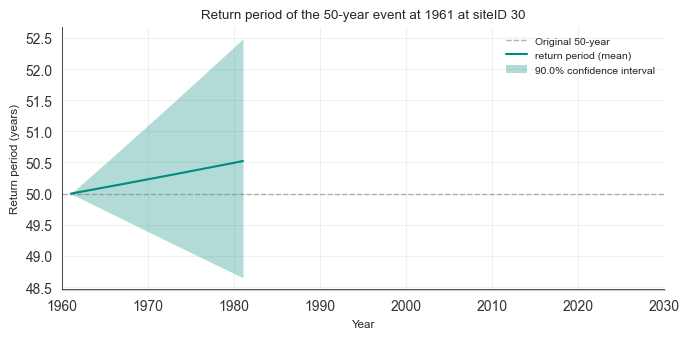

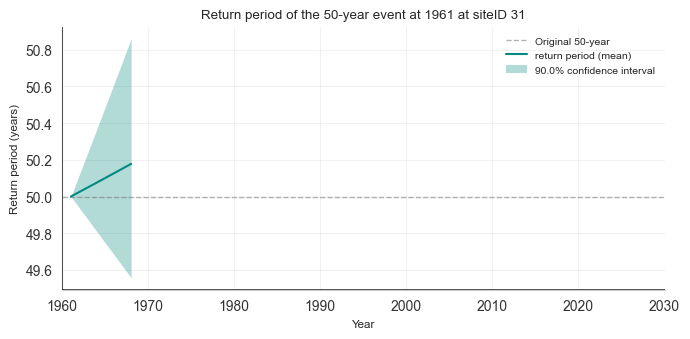

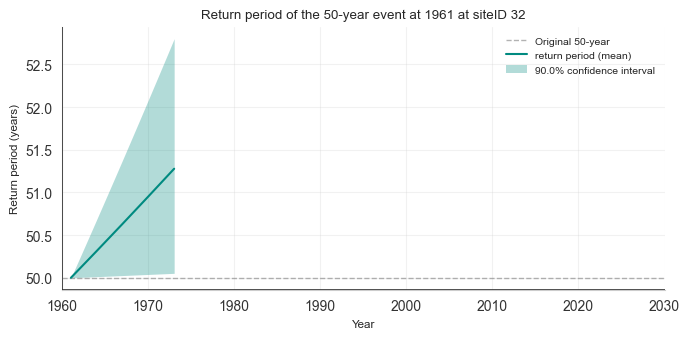

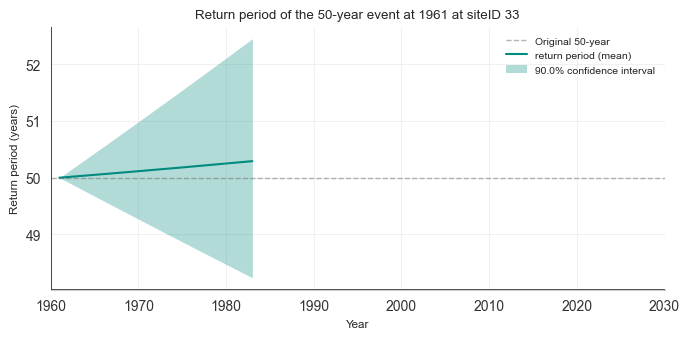

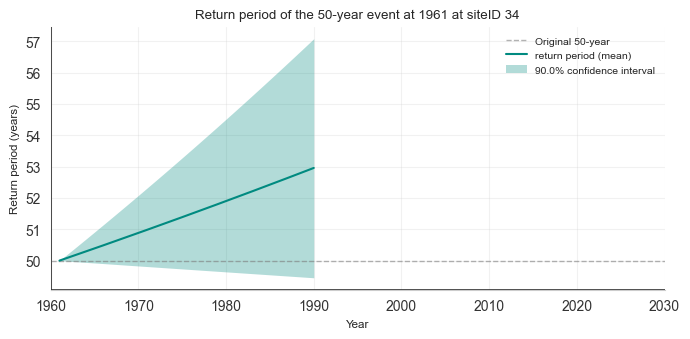

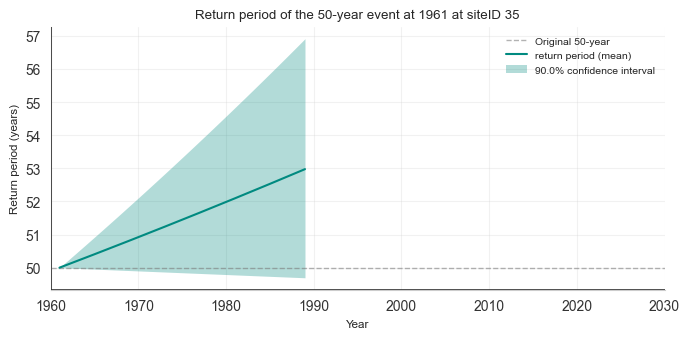

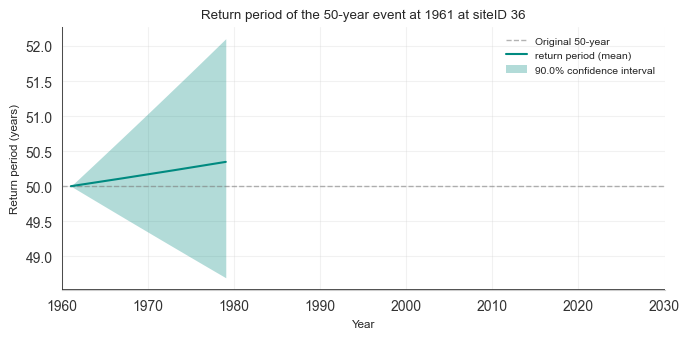

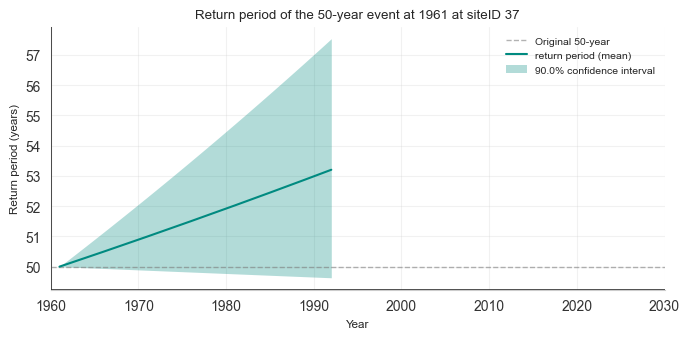

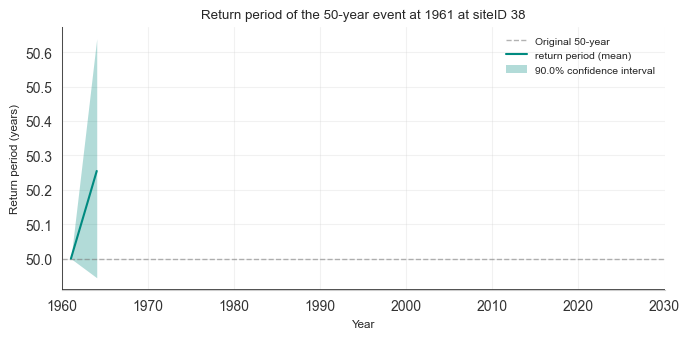

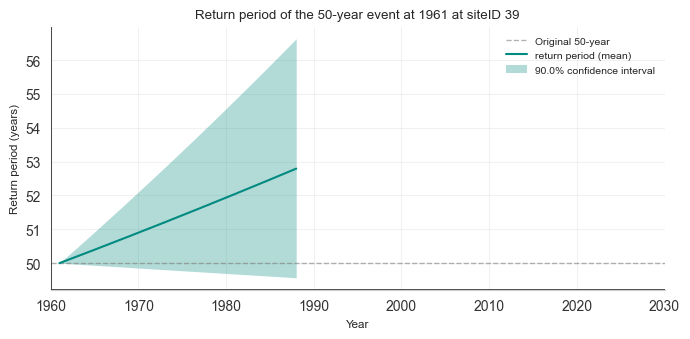

In [9]:
for loc_id in results.keys():
        fig, ax_bottom_left = plt.subplots(figsize=(7, 3.5))
        dbplt.plot_equivalent_return_period_evolution(
                ax=ax_bottom_left, T_ref=RETURN_PERIOD_EVAL, t_ref=T_EVAL_BASE, loc_id=loc_id,
                return_period_ns=results[loc_id]['nonstationary']['return_period'], color_ns='#008A80FF', 
                ci_level=CONFIDENCE_INTERVAL*100, fs=12*0.7
        )

In [ ]:
_ = [gev.print_report(results[loc_ex], loc_ex) for loc_ex in results]

## Plot Figures 

NOTE the result overview refers to the bootstrapped (of Fisher information), hence the (occasional) difference between stationary and non-stationary approach. 

In [ ]:
print(f'Process siteID {loc_id}')

fig = dbplt.plot_pooled_analysis_v2(
    result=results[loc_id], site_id=loc_id, t_eval_base=1961, return_period_base=50,
    return_periods=RETURN_PERIODS, display_results=True,
    plot_evolution=[int(i.split('-')[0]) for i in PLOT_PERIOD_EVOLUTION],
    leg_comparison_x=0.075, leg_comparison_y=0.45, box_parameters_x=0.35,  box_parameters_y= 0.95,
    linestyle_trends = ['-', '--', '-.', ':', (0, (1, 1)), (0, (5, 10))], fontsize=12, figsize=(15, 7.5),
    confidence_interval_pc=CONFIDENCE_INTERVAL
    )

## Store Result(s)

In [ ]:
today_ = str(datetime.today().date().isoformat())   
path_child_folder = Path(path_export) / f"{today_}"

ut.save_pooled_results(results=results, data=None, base_dir=path_child_folder)

In [ ]:
fig_dir = Path(path_child_folder) / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

for loc_id, result in results.items():   
    fig = dbplt.plot_pooled_analysis_v2(
        result=result, site_id=loc_id, t_eval_base=T_EVAL_BASE, return_period_base=RETURN_PERIOD_EVAL,
        return_periods=RETURN_PERIODS, display_results=True, confidence_interval_pc=CONFIDENCE_INTERVAL,
        plot_evolution=[int(i.split('-')[0]) for i in PLOT_PERIOD_EVOLUTION],
        leg_comparison_x=0.075, leg_comparison_y=0.45, box_parameters_x=0.35,  box_parameters_y= 0.95,
        linestyle_trends = ['-', '--', '-.', ':', (0, (1, 1)), (0, (5, 10))], fontsize=12, figsize=(15, 7.5),
        )

    lat = str(result['LatLon'][0].round(3))
    lon = str(result['LatLon'][1].round(3))
    country = result['location_info'].split(' ')[-1].strip()

    fig.savefig(
        fig_dir / f"location_{loc_id}_{country}_{lat}_{lon}_pooledGEVanalysis.png", dpi=150, bbox_inches="tight"
        )
    plt.close(fig)

# Annual Stationary GEV Analysis

For annual stationary GEV, each yearly fit likely has fewer data samples.
> For a small sample size for a 3-parameter GEV, especially with negative shape, Hessian becomes unstable because:
- Some years will have near-degenerate scale
- Some years will have shape near boundary
- Finite differences step outside parameter support
- Log-likelihood returns inf or nan
- Second derivative formula explodes


> Solution
Compute MLE for annual stationary for 3 parameters and then fit the regression incl uncertainty


**NOTE** in case, run `Import Data` and `Prepare Data` first

In [ ]:
results_all = ut.select_allowed_locations(
    dic_data_per_location=dic_data_per_location, start_loc=start_location, end_loc=end_location
    )
results_all.keys()

In [ ]:
results_annual_stat_all = gev.fit_all_locations(results_all, n_jobs=-1)

In [ ]:
try:
    for loc_id, df_yearly in results_annual_stat_all.items():
        if loc_id in results:
            results[loc_id]['annual_stationary'] = df_yearly
        else:
            results[loc_id] = {'annual_stationary': df_yearly}

except:
    results = {}
    results[loc_id] = dict({'annual_stationary': results_annual_stat_all})

In [ ]:
try:
    dir_export = path_child_folder
except:
    today_ = str(datetime.today().date().isoformat())   
    dir_export = Path(path_export) / f"{today_}"
    
ut.store_annual_stat_results(results_annual_stat_all, dir_export)

# Regression Analysis for Location Parameter μ

- Nonstationary pooled uses already weighting in likelihood > standard regression on fitted mu0/mu1
- Annual stationary needs to actively be included in regression when n_obs vary for years

### Import Data if Needed

In [ ]:
dir_import = '../output/gev_analysis/2026-03-02/'

In [ ]:
with open(dir_import + 'stationary_per_year.pkl', "rb") as f:
    results_annual_stat_all = pickle.load(f)
    
with open(dir_import + 'nonstationary.pkl', "rb") as f:
    results_nonstat_all = pickle.load(f)
    
with open(dir_import + 'LatLon.pkl', "rb") as f:
    location_geo_info = pickle.load(f)
    
with open(dir_import + 'location_info.pkl', "rb") as f:
    location_point_info = pickle.load(f)

In [ ]:
loc_id = list(results_annual_stat_all.keys())[1]
loc_id

In [ ]:
years_, dic_trend = gev.prepare_for_regression(
    annual_stationary=results_annual_stat_all[loc_id], 
    nonstationary=results_nonstat_all[loc_id],
    years_mean=results_nonstat_all[loc_id]['years_mean'], 
    years_std=results_nonstat_all[loc_id]['years_std'], 
    hindcast_start=HINDCAST_START, hindcast_end=HINDCAST_END,
    z_percentile=1.96, factor_m_to_mm=1000
    ) 

In [ ]:
fig_reg = dbplt.plot_location_regression(
    loc_id, years_, dic_trend, results_annual_stat_all[loc_id], 
    axes_color='#333333', markers_color="#99E3DDFF", colors_reg=['#CAA5C2FF',  '#005C55FF'], fontsize=12
    )

## Store regression plot

In [ ]:
try:
    dir_export = path_child_folder
except:
    today_ = str(datetime.today().date().isoformat())   
    dir_export = Path(path_export) / f"{today_}"

ut.store_location_regression(fig_reg,loc_id, location_geo_info[loc_id], location_point_info[loc_id], dir_export)